In [1]:
from src.rttpc.pipeline import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Future TODO: Load image from some kind of buffer maybe? (for testing)
image = Image.open(
    "./Rellis_3D_image_example/pylon_camera_node/frame000002-1581624652_949.jpg"
    #"./Rellis_3D_image_example/pylon_camera_node/frame000000-1581623790_349.jpg"
)
camera_intrinsics = [2813.643275, 2808.326079, 969.285772, 624.049972]
"""
q:
    w: -0.50507811
    x: 0.51206185
    y: 0.49024953
    z: -0.49228464
t:
    x: -0.13165462
    y: 0.03870398
    z: -0.17253834
"""
T_cam2lidar = np.eye(4)
T_cam2lidar[0:3,0:3] = quaternion_to_rotation_matrix([-0.50507811, 0.51206185, 0.49024953, -0.49228464])
T_cam2lidar[0,3] = -0.13165462
T_cam2lidar[1,3] = 0.03870398
T_cam2lidar[2,3] = -0.17253834

T_lidar2base = np.diag([-1.0, 1.0, -1.0, 1.0])
T_cam2base = T_lidar2base @ T_cam2lidar
T_base2map = np.eye(4) # map is initialized at inital robot pose 

    
positive_queries = [
    "a photo of a flat clear road",
    "a photo of a walkable dirt path",
    "a photo of flat grassy ground",
]

negative_queries = [
    "a photo of the sky",
    "a photo of a wall",
    "a photo of deep water",
    "a photo of a puddle",
    "a photo of a tree",
    "a photo of trees",
    "a photo of a large rock",
    "a photo of a person",
    "a photo of a cliff",
    "a photo of a bush"
]

sam_model, sam_processor, sam_device = load_sam_model()

clip_model, clip_processor, clip_device = load_clip_model()

da_model, da_processor, da_device = load_da_model() # Maybe want to load both indoor and outdoor models and use CLIP to select which one to use

# Pre-process queries for faster scoring (shaves off roughly 1 second of processing time per image)
safety_embeddings, trav_embeddings = prepare_text_embeddings(positive_queries, negative_queries, clip_model, clip_processor, clip_device)

logger.info(f"All models loaded.")

2026-10-08 23:25:26,629 [INFO] rttpc.load_models: Loading SAM model: facebook/sam-vit-base...
2026-10-08 23:25:26,794 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/facebook/sam-vit-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-10-08 23:25:26,934 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-10-08 23:25:27,071 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-10-08 23:25:27,206 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-10-08 23:25:27,342 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-10-08 23:25:27,478 [INFO] httpx: HTTP Request: HEA

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

2026-10-08 23:25:29,497 [INFO] rttpc.load_models: SAM model loaded on device: cuda
2026-10-08 23:25:29,498 [INFO] rttpc.load_models: Loading CLIP model: openai/clip-vit-base-patch32...
2026-10-08 23:25:29,654 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-10-08 23:25:29,793 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-10-08 23:25:29,929 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-10-08 23:25:30,066 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-10-08 23:25:30,215 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-pat

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-10-08 23:25:33,595 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32 "HTTP/1.1 200 OK"
2026-10-08 23:25:33,741 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/main "HTTP/1.1 200 OK"
2026-10-08 23:25:33,900 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
2026-10-08 23:25:34,045 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-10-08 23:25:34,137 [INFO] rttpc.load_models: CLIP model loaded on device: cuda
2026-10-08 23:25:34,138 [INFO] rttpc.load_models: Loading DepthAnything model: depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf...
2026-10-08 23:25:34,182 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 No

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

2026-10-08 23:25:35,349 [INFO] rttpc.load_models: DepthAnything model loaded on device: cuda
2026-10-08 23:25:35,945 [INFO] src.rttpc.pipeline: All models loaded.


2026-10-08 23:25:36,964 [INFO] src.rttpc.pipeline: DepthAnything processing time: 1.0030s
2026-10-08 23:25:36,965 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-08 23:25:37,478 [INFO] src.rttpc.pipeline: Generated 13 unique segment proposals
2026-10-08 23:25:37,479 [INFO] src.rttpc.pipeline: SAM processing time: 0.5148s
2026-10-08 23:25:37,732 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2534s (avg 0.0195s per segment)
2026-10-08 23:25:37,733 [INFO] src.rttpc.pipeline: Total processing time: 1.7713s
2026-10-08 23:25:37,733 [INFO] src.rttpc.pipeline: Visualizing results...


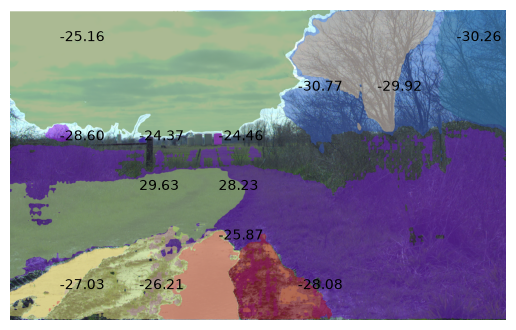

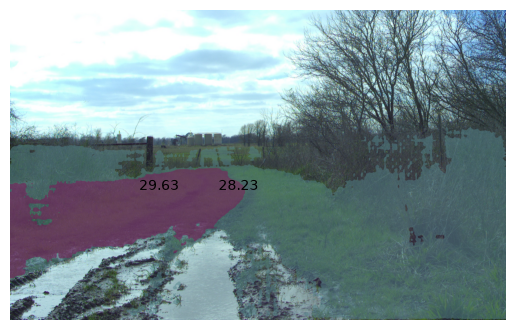

libEGL warning: failed to get driver name for fd -1

libEGL warning: MESA-LOADER: failed to retrieve device information

libEGL warning: failed to get driver name for fd -1

MESA: error: ZINK: failed to choose pdev
libEGL warning: egl: failed to create dri2 screen


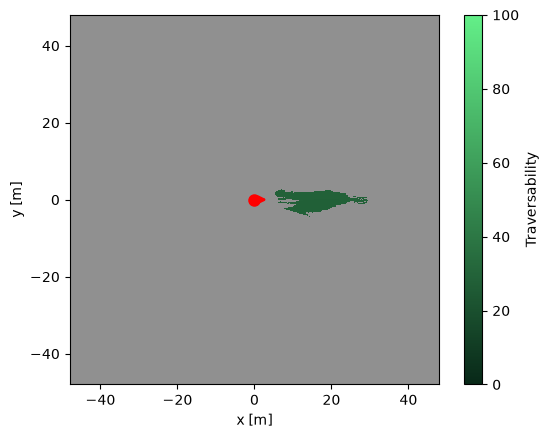

In [ ]:
# Initialize map
trav_map = TraversabilityMap(
    h = 96,
    w = 96,
    offset_x = -48, # 0 at map center
    offset_y = -48, # 0 at map center
    resolution= 0.10,
    decay_time=3.0
)

# Depth time :)
start_processing_time = time.perf_counter()

depth = get_image_depth(image, da_model, da_processor, da_device)

pcd, pixel_indices = image_to_world(image, depth, camera_intrinsics)

# Fit only nearby points in the bottom half of the image to avoid sky.
ground_fit_min_row = 0.5 * image.height
ground_fit_max_depth = 20.0  # metres (camera z)
fit_mask = (
    (pixel_indices // image.width >= ground_fit_min_row)
    & (np.asarray(pcd.points)[:, 2] <= ground_fit_max_depth)
)
plane = get_ground_plane(pcd.select_by_index(np.flatnonzero(fit_mask)))
    
ground_indices = gather_ground_indices(pcd, plane)

end_da_processing_time = time.perf_counter()

logger.info(f"DepthAnything processing time: {(end_da_processing_time-start_processing_time):.4f}s")

# SAM time :D
segmentations = generate_sam_masks(image, sam_model, sam_processor, sam_device)

end_SAM_processing_time = time.perf_counter()
logger.info(f"SAM processing time: {(end_SAM_processing_time-end_da_processing_time):.4f}s")

viz_pcd = open3d.geometry.PointCloud()
for segment in segmentations:
    mask = segment["mask"]

    segment["trav_score"] = 100 * score_with_clip(image, mask, clip_model, clip_processor, clip_device, safety_embeddings, trav_embeddings)
    #visualize_segment_scores([segment], image)

    if segment["trav_score"] is not None and segment["trav_score"] > 0.01:
        # Sample the image mask at each ground point's source pixel, then
        # retain the corresponding indices into the original cloud.
        keep = mask.ravel()[pixel_indices[ground_indices]]
        trav_indices = ground_indices[keep]
        trav_pcd = pcd.select_by_index(trav_indices)
        # Transform trav_pcd into world frame (skipped for now, robot->world will be defined later)
        points_world = trav_pcd.transform(T_cam2base)
        map_indices = world_coords_to_map_indices(np.asarray(points_world.points), trav_map)
        # Right now, we just overwrite cells directly. Realistically, I'd rather add the scores to already existing scores to increase the confidence,
        # since multiple observations should make us more confident. 
        trav_map[map_indices] = segment["trav_score"]

        viz_pcd.points.extend(points_world.points)

end_CLIP_processing_time = time.perf_counter()
logger.info(f"CLIP processing time: {(end_CLIP_processing_time-end_SAM_processing_time):.4f}s (avg {(end_CLIP_processing_time-end_SAM_processing_time)/len(segmentations):.4f}s per segment)")

logger.info(f"Total processing time: {(end_CLIP_processing_time-start_processing_time):.4f}s")

logger.info("Visualizing results...")
visualize_segment_scores(segmentations, image)
visualize_traversable_segments(segmentations, image)
# open3d.visualization.draw_geometries([pcd.transform(T_cam2base), viz_pcd.paint_uniform_color([0,1,0])])

pose = (0,0,0)
show_traversability(trav_map, pose)